# 00 — Profile Token Distribution

**Mục đích:** Đo token length distribution của prompt + completion trên dữ liệu thực tế.  
Kết quả dùng để chốt `max_seq_length` và `max_new_tokens` trước khi train.

**Không cần GPU.** Chạy được trên máy local hoặc Colab free tier.

**Output:** `profile_results.json`, `token_distribution.png`

In [1]:
# On Colab: uncomment and run this cell first
!pip install transformers datasets --quiet

In [2]:
import json
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from datasets import load_dataset

# ---- Config ----
MODEL_NAME = "Qwen/Qwen3.5-4B-Base"
DATASET_NAME = "SeanSunny/items_tv_v6"
PROFILE_SAMPLE = 1000
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
print("Config OK")

Config OK


In [3]:
# Load tokenizer (downloads ~5MB config files, no model weights)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocab size: {tokenizer.vocab_size:,}")

# Vietnamese round-trip test
test_vi = "Điện thoại Samsung Galaxy S25 Ultra 256GB màu Đen Titanium"
encoded = tokenizer.encode(test_vi)
decoded = tokenizer.decode(encoded, skip_special_tokens=True)
print(f"Test string : {test_vi}")
print(f"Token count : {len(encoded)}")
print(f"Decoded back: {decoded}")
print(f"Round-trip  : {'OK' if decoded.strip() == test_vi.strip() else 'MISMATCH — check tokenizer'}")

config.json: 0.00B [00:00, ?B/s]

You are using a model of type qwen3_5 to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Vocab size: 248,044
Test string : Điện thoại Samsung Galaxy S25 Ultra 256GB màu Đen Titanium
Token count : 16
Decoded back: Điện thoại Samsung Galaxy S25 Ultra 256GB màu Đen Titanium
Round-trip  : OK


In [4]:
# Load dataset (public, no token needed)
ds = load_dataset(DATASET_NAME)
print(ds)

# Detect split names
splits = list(ds.keys())
val_key = "val" if "val" in splits else "validation"
print(f"\nSplits: {splits}")
print(f"Train: {len(ds['train']):,} | Val: {len(ds[val_key]):,} | Test: {len(ds['test']):,}")
print(f"Columns: {ds['train'].column_names}")

README.md:   0%|          | 0.00/737 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/51.0M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.32M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/110000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'category', 'price', 'full', 'brand', 'summary', 'prompt', 'id'],
        num_rows: 110000
    })
    validation: Dataset({
        features: ['title', 'category', 'price', 'full', 'brand', 'summary', 'prompt', 'id'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['title', 'category', 'price', 'full', 'brand', 'summary', 'prompt', 'id'],
        num_rows: 5000
    })
})

Splits: ['train', 'validation', 'test']
Train: 110,000 | Val: 5,000 | Test: 5,000
Columns: ['title', 'category', 'price', 'full', 'brand', 'summary', 'prompt', 'id']


In [5]:
# Sample 1000 random train items
train = ds["train"]
indices = random.sample(range(len(train)), PROFILE_SAMPLE)
sample = train.select(indices)
print(f"Sampled {len(sample)} items")

Sampled 1000 items


In [6]:
# Prompt template (canonical — same as utils/prompt_builder.py)
PROMPT_TEMPLATE = """Sản phẩm này có giá bao nhiêu ?
Tiêu đề: {title}
Danh mục: {category}
Thương hiệu: {brand}
Mô tả: {description}
Thông số: {features}

Giá là: """


def build_prompt(item: dict) -> str:
    return PROMPT_TEMPLATE.format(
        title=item.get("title") or "",
        category=item.get("category") or "",
        brand=item.get("brand") or "Không rõ",
        description=item.get("description") or "Không có mô tả",
        features=item.get("features") or "Không có thông số",
    )


def build_completion(price: float) -> str:
    """Train/val completion: round(price/1000) as string."""
    return str(int(round(price / 1000)))


# Show one sample
item0 = dict(sample[0])
print("=== Sample prompt ===")
print(build_prompt(item0))
print(f"COMPLETION: {build_completion(item0['price'])}")

=== Sample prompt ===
Sản phẩm này có giá bao nhiêu ?
Tiêu đề: [Ảnh Thật 100%] [FULLBOX] Giày Cao Gót Mũi Nhọn Phối Dây Quai Gài Gót Tròn Cao 5CM - Hàng Quảng Châu
Danh mục: Thời Trang
Thương hiệu: Không rõ
Mô tả: Không có mô tả
Thông số: Không có thông số

Giá là: 
COMPLETION: 256


In [7]:
# Tokenize all samples and collect lengths
from tqdm.auto import tqdm

prompt_lens = []
completion_lens = []
full_lens = []

for item in tqdm(sample, desc="Tokenizing"):
    item = dict(item)
    prompt = build_prompt(item)
    completion = build_completion(item["price"])

    # Note: tokenize prompt and full separately to get accurate lengths
    p_ids = tokenizer.encode(prompt, add_special_tokens=False)
    c_ids = tokenizer.encode(completion, add_special_tokens=False)
    f_ids = tokenizer.encode(prompt + completion, add_special_tokens=False)

    prompt_lens.append(len(p_ids))
    completion_lens.append(len(c_ids))
    full_lens.append(len(f_ids))

prompt_lens = np.array(prompt_lens)
completion_lens = np.array(completion_lens)
full_lens = np.array(full_lens)

print(f"Tokenized {len(prompt_lens)} samples")

Tokenizing:   0%|          | 0/1000 [00:00<?, ?it/s]

Tokenized 1000 samples


In [8]:
# Compute percentile stats
def pstats(arr):
    return {
        "p50": int(np.percentile(arr, 50)),
        "p90": int(np.percentile(arr, 90)),
        "p95": int(np.percentile(arr, 95)),
        "p99": int(np.percentile(arr, 99)),
        "max": int(arr.max()),
        "mean": round(float(arr.mean()), 1),
    }

prompt_stats = pstats(prompt_lens)
completion_stats = pstats(completion_lens)
full_stats = pstats(full_lens)

print("Prompt tokens    :", prompt_stats)
print("Completion tokens:", completion_stats)
print("Full tokens      :", full_stats)

Prompt tokens    : {'p50': 75, 'p90': 94, 'p95': 101, 'p99': 122, 'max': 156, 'mean': 77.4}
Completion tokens: {'p50': 3, 'p90': 4, 'p95': 4, 'p99': 5, 'max': 5, 'mean': 3.1}
Full tokens      : {'p50': 79, 'p90': 98, 'p95': 104, 'p99': 125, 'max': 158, 'mean': 80.5}


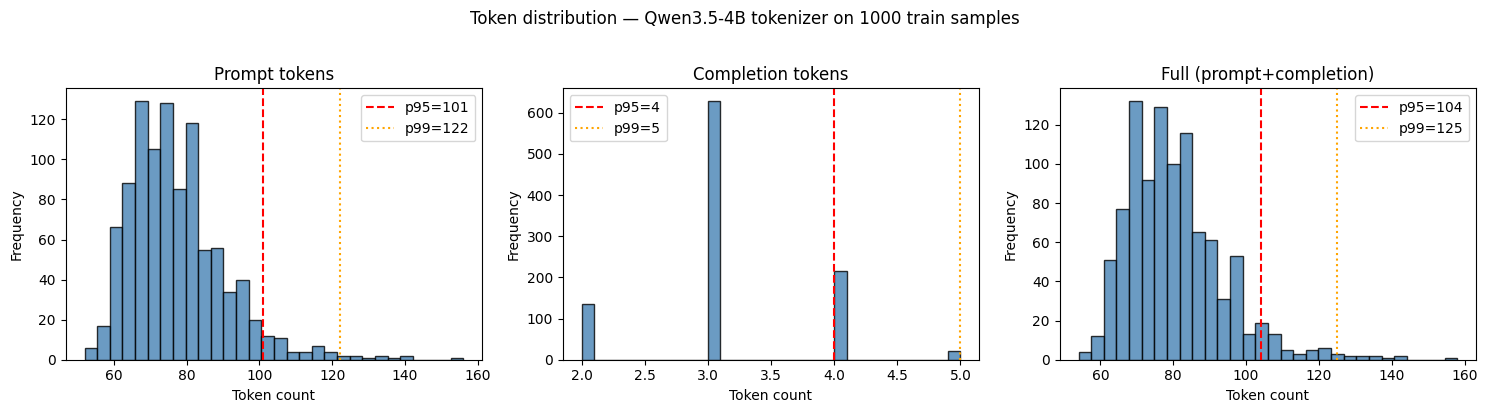

Saved token_distribution.png


In [9]:
# Plot histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title, stats in zip(
    axes,
    [prompt_lens, completion_lens, full_lens],
    ["Prompt tokens", "Completion tokens", "Full (prompt+completion)"],
    [prompt_stats, completion_stats, full_stats],
):
    ax.hist(data, bins=30, edgecolor="black", color="steelblue", alpha=0.8)
    ax.axvline(stats["p95"], color="red", linestyle="--", label=f'p95={stats["p95"]}')
    ax.axvline(stats["p99"], color="orange", linestyle=":", label=f'p99={stats["p99"]}')
    ax.set_title(title)
    ax.set_xlabel("Token count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle(f"Token distribution — Qwen3.5-4B tokenizer on {PROFILE_SAMPLE} train samples", y=1.02)
plt.tight_layout()
plt.savefig("token_distribution.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved token_distribution.png")

In [10]:
# Compute recommendations
p95_full = full_stats["p95"]
p99_completion = completion_stats["p99"]

# Round p95_full up to nearest 64
recommended_seq = math.ceil(p95_full / 64) * 64
recommended_new_tokens = p99_completion + 1

print(f"p95 full tokens     : {p95_full}")
print(f"p99 completion toks : {p99_completion}")
print()
print(f"==> recommended max_seq_length  = {recommended_seq}")
print(f"==> recommended max_new_tokens  = {recommended_new_tokens}")
print()
print("English reference (items_llm_v6): prompt ~110-128 tokens, completion 1-3 tokens")
print(f"Vietnamese ratio vs English (prompt p95): {full_stats['p95']} / ~128 = {full_stats['p95']/128:.2f}x")

p95 full tokens     : 104
p99 completion toks : 5

==> recommended max_seq_length  = 128
==> recommended max_new_tokens  = 6

English reference (items_llm_v6): prompt ~110-128 tokens, completion 1-3 tokens
Vietnamese ratio vs English (prompt p95): 104 / ~128 = 0.81x


In [11]:
# Save profile_results.json
results = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "sample_size": PROFILE_SAMPLE,
    "seed": SEED,
    "prompt_tokens": prompt_stats,
    "completion_tokens": completion_stats,
    "full_tokens": full_stats,
    "recommended_max_seq_length": recommended_seq,
    "recommended_max_new_tokens": recommended_new_tokens,
}

with open("profile_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved profile_results.json")
print(json.dumps(results, indent=2, ensure_ascii=False))

Saved profile_results.json
{
  "model": "Qwen/Qwen3.5-4B-Base",
  "dataset": "SeanSunny/items_tv_v6",
  "sample_size": 1000,
  "seed": 42,
  "prompt_tokens": {
    "p50": 75,
    "p90": 94,
    "p95": 101,
    "p99": 122,
    "max": 156,
    "mean": 77.4
  },
  "completion_tokens": {
    "p50": 3,
    "p90": 4,
    "p95": 4,
    "p99": 5,
    "max": 5,
    "mean": 3.1
  },
  "full_tokens": {
    "p50": 79,
    "p90": 98,
    "p95": 104,
    "p99": 125,
    "max": 158,
    "mean": 80.5
  },
  "recommended_max_seq_length": 128,
  "recommended_max_new_tokens": 6
}


## Ket qua Phase 0 Notebook 1

**STOP:** Share noi dung `profile_results.json` va `token_distribution.png` voi Claude.  
Claude se confirm `max_seq_length` va `max_new_tokens` truoc khi sang Notebook 01.